# Yield Simulator for W2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [14]:
%reload_ext autoreload
%autoreload 2

In [15]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator
from types import SimpleNamespace
import os

In [26]:
import joblib
import yaml
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

waf_stack = joblib.load("waf_stack.joblib")

In [80]:
def draw_w2w_stack_3d(waf_stack, itf_pitch=100.0, fig_size=(10, 8), dpi=300,
                        draw_pad_yield_map_option=None, draw_voids=True):
        """
        waf_itf: the wafer interface object containing the die and pad information for each layer
        itf_pitch: the distance between interfaces in the z direction (can be adjusted for better visualization)
        """
        fig = plt.figure(figsize=fig_size, dpi=dpi)
        ax = fig.add_subplot(111, projection='3d')

        waf_itf_r = 150000
        ax.set_xlim(-waf_itf_r * 1.1, waf_itf_r * 1.1)
        ax.set_ylim(-waf_itf_r * 1.1, waf_itf_r * 1.1)
        ax.set_zlim(-itf_pitch, itf_pitch * (len(waf_stack.interfaces.interface_dict) + 1))
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Stack (Wafer Index)")

        # Draw each interface
        for itf_idx, waf_itf in enumerate(waf_stack.interfaces.interface_dict.values()):
            z = itf_idx * itf_pitch

            # Draw the wafer outline (circle) for each interface
            theta = np.linspace(0, 2*np.pi, 200)
            cx = waf_itf_r * np.cos(theta)
            cy = waf_itf_r * np.sin(theta)
            ax.plot(cx, cy, zs=z, zdir='z', linewidth=0.1, color='gray', alpha=0.5)

            # Draw dies for each interface
            for die in waf_itf.die_list:
                polygon_coords = np.array([
                    die.vertices_coords[0],  # top-left
                    die.vertices_coords[1],  # top-right
                    die.vertices_coords[3],  # bottom-right
                    die.vertices_coords[2],  # bottom-left
                ], dtype=float)

                # Determine edge color based on die status
                if die.survival is False:
                    face_color = (1.0, 0.2, 0.2, 0.3)   # 红：强
                elif getattr(die, "voids_occur", False):
                    face_color = (0.2, 0.8, 0.2, 0.3)   # 绿：中
                else:
                    face_color = (0.6, 0.6, 0.9, 0.05)  # 蓝灰：弱背景

                verts3d = [(x, y, z) for x, y in polygon_coords]
                poly = Poly3DCollection(
                    [verts3d],
                    facecolors=[face_color],   # 透明面，但仍然是“有一个面颜色”
                    edgecolors='none',     # 注意也用 list 包起来，长度=1
                    linewidths=0.6,
                    alpha=0.2
                )
                ax.add_collection3d(poly)

                # pad_yield_map: Directly mapping 2D images in 3D is complicated (requires converting 2D image to mesh/texture)
                # Suggestion: For 3D, focus on die status/voids structure; use single-layer 2D output or plotly texture for pad map.
                # If you strongly need it, I can also provide a version that samples imshow into point cloud/small cubes.

            # # Draw voids (simplified: use 3D scatter to represent centers, size ~ radius)
            # if draw_voids and hasattr(waf_itf, "voids"):
            #     vx = np.array([v[0] for v in waf_itf.voids], dtype=float)
            #     vy = np.array([v[1] for v in waf_itf.voids], dtype=float)
            #     vr = np.array([v[2] for v in waf_itf.voids], dtype=float)

            #     ax.scatter(vx, vy, zs=np.full_like(vx, z), s=np.clip(vr, 1, None)*2, alpha=0.4)

        ax.view_init(elev=25, azim=-55)  # 视角可调
        plt.tight_layout()
        plt.show()

        # Save the figure
        fig.savefig("w2w_stack_3d.png")

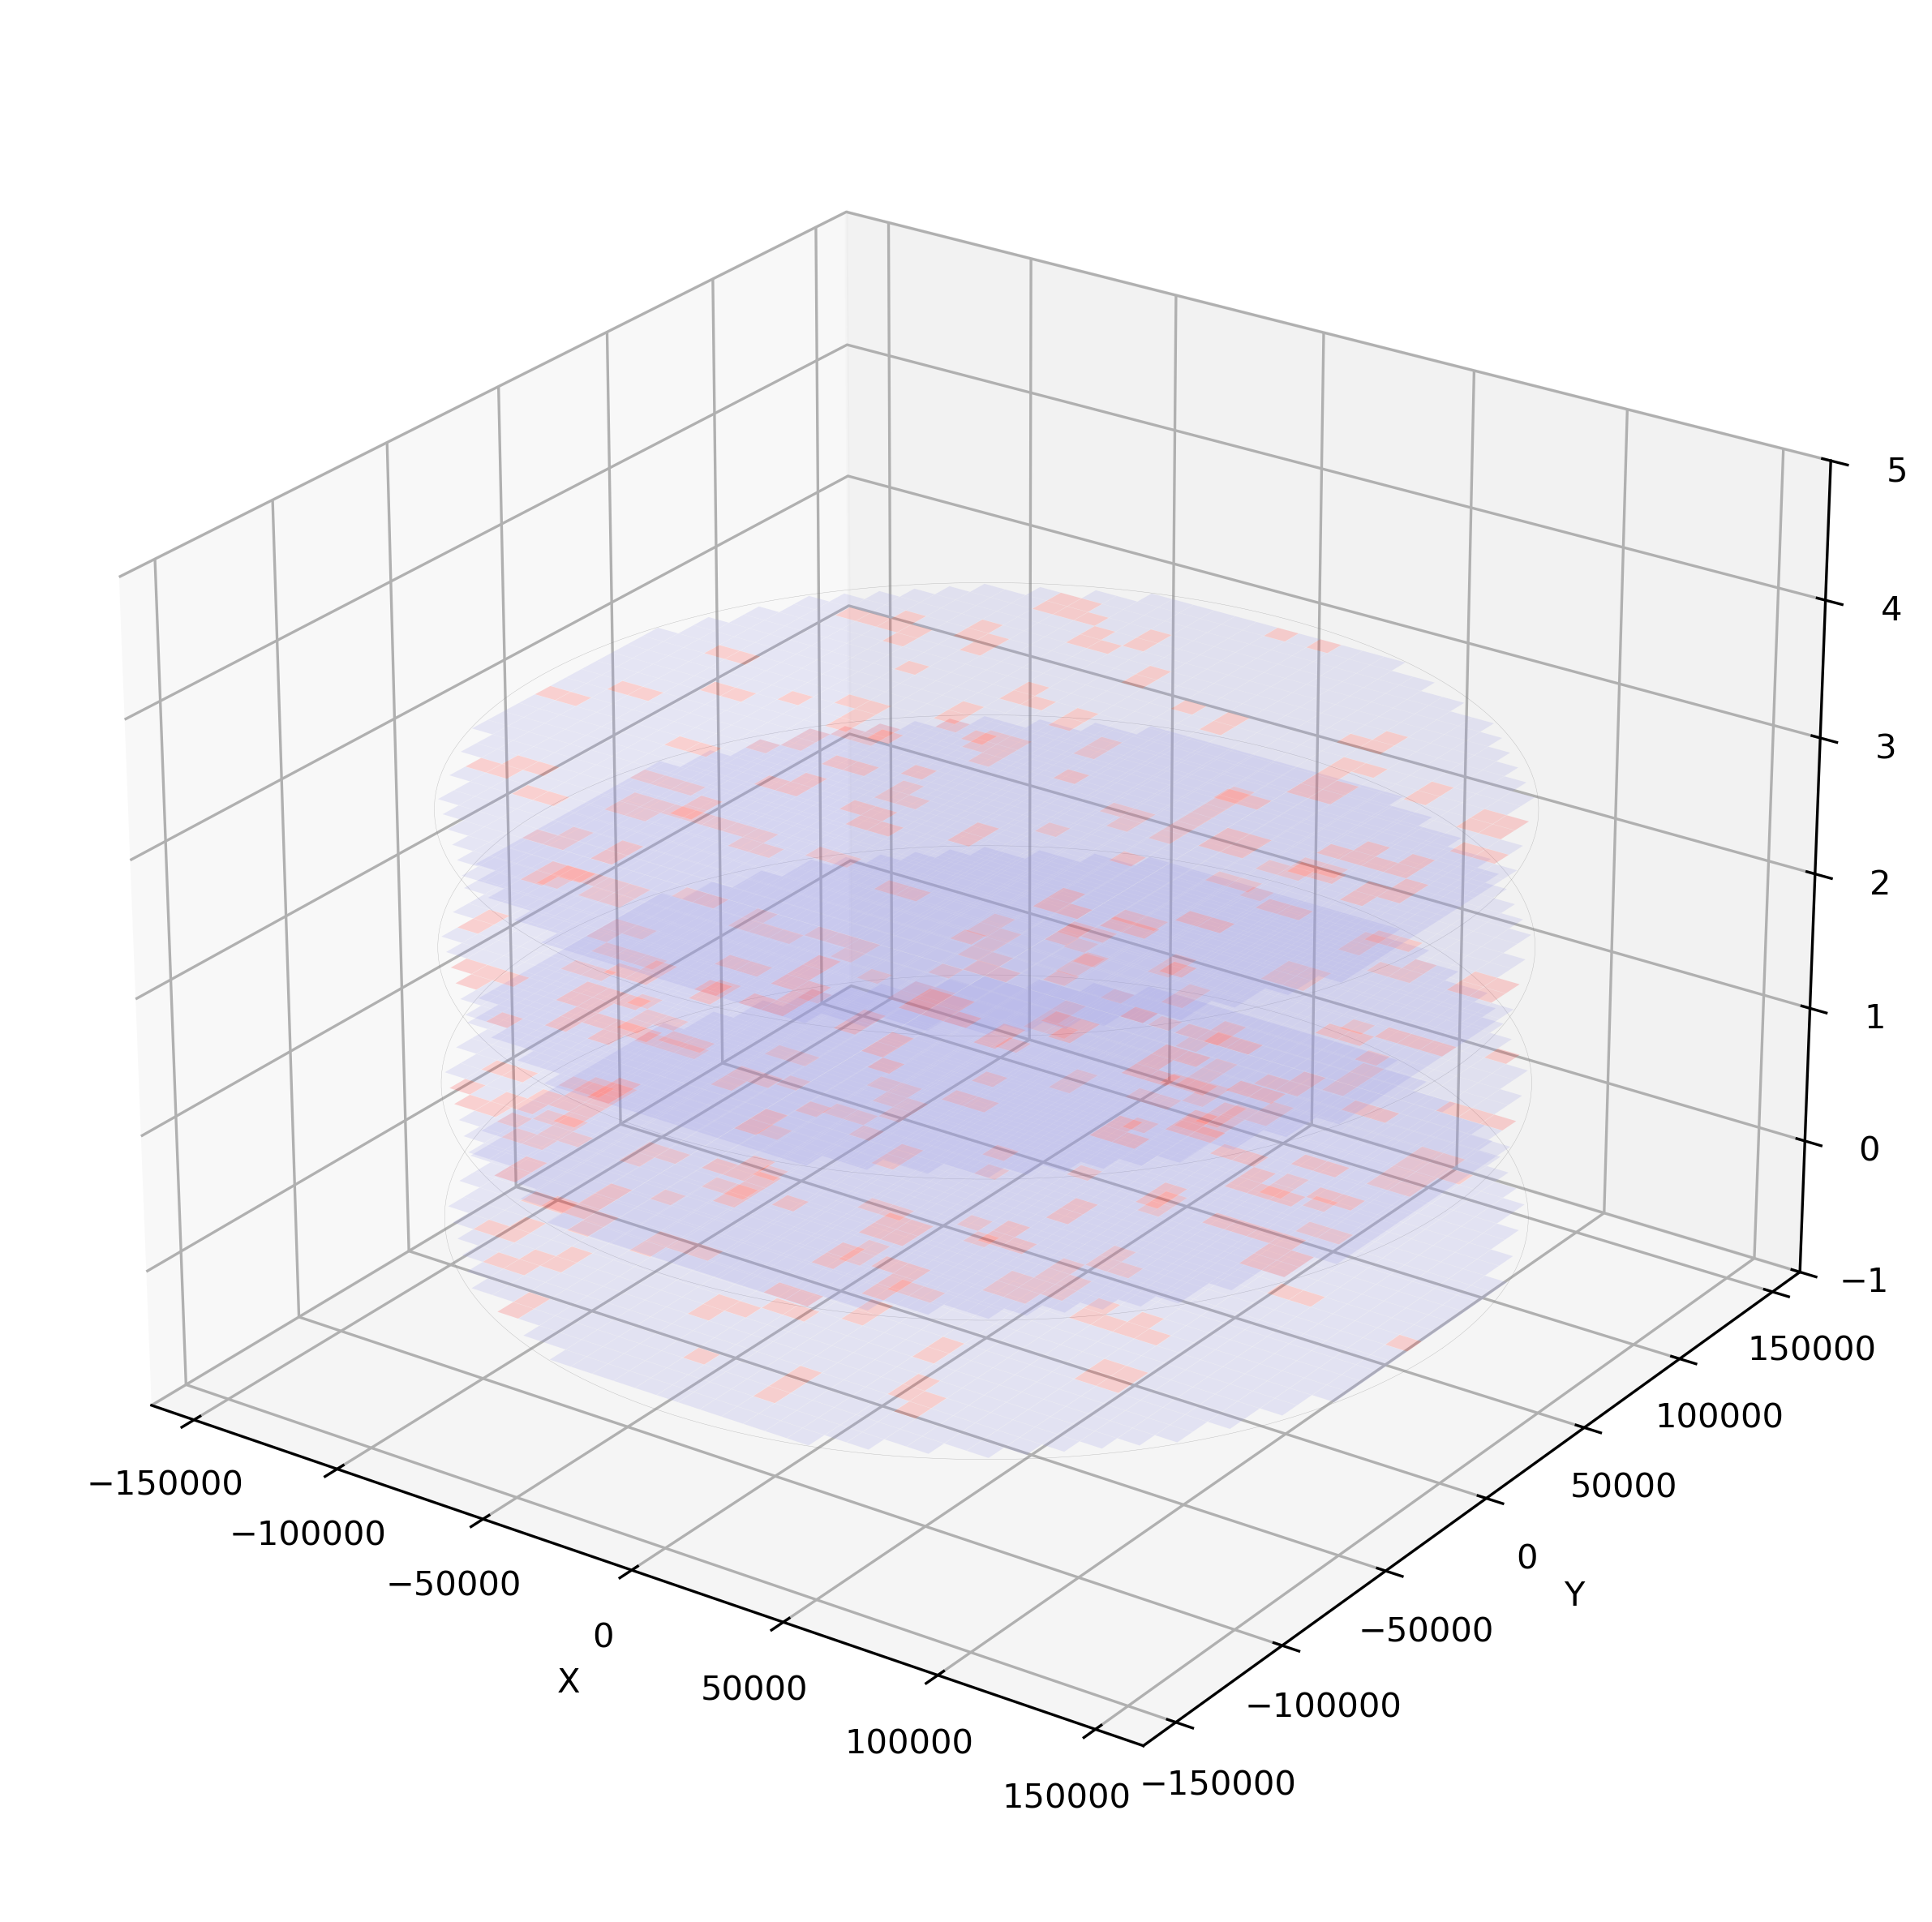

In [81]:
draw_w2w_stack_3d(waf_stack, itf_pitch=1.0)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle

def draw_w2w_stack_2d(waf_stack, fig_size=(10, 8), dpi=300, draw_voids=True,
                      waf_itf_r=150000, overlay_all_layers=True,
                      draw_wafer_outline_once=True):
    """
    2D top-view overlay of all wafer interfaces (layers) on the same XY plane.

    overlay_all_layers:
        True  -> 所有 layer 叠加在一张图上
        False -> 只画第 0 层（你也可以改成传入 layer index）
    draw_wafer_outline_once:
        True  -> wafer 圆只画一次（推荐）
        False -> 每层都画一次（一般没必要）
    """
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    ax.set_aspect("equal", adjustable="box")

    # 轴范围
    ax.set_xlim(-waf_itf_r * 1.1, waf_itf_r * 1.1)
    ax.set_ylim(-waf_itf_r * 1.1, waf_itf_r * 1.1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("W2W Stack Top-View (2D Overlay)")

    # wafer outline（只画一次更干净）
    if draw_wafer_outline_once:
        ax.add_patch(Circle((0, 0), waf_itf_r, fill=False, linewidth=0.6,
                            edgecolor="gray", alpha=0.7))

    # 遍历 interfaces
    for itf_idx, waf_itf in enumerate(waf_stack.interfaces.interface_dict.values()):
        if (not overlay_all_layers) and itf_idx != 0:
            continue

        # 如果你想每层都画 wafer outline（一般不推荐）
        if not draw_wafer_outline_once:
            ax.add_patch(Circle((0, 0), waf_itf_r, fill=False, linewidth=0.1,
                                edgecolor="gray", alpha=0.5))

        # 画 dies（用面颜色，不画边）
        for die in waf_itf.die_list:
            vc = np.asarray(die.vertices_coords, dtype=float)
            if vc.ndim != 2 or vc.shape[0] < 4 or vc.shape[1] < 2:
                continue

            polygon_coords = np.array([vc[0], vc[1], vc[3], vc[2]], dtype=float)

            # 你的配色逻辑（保持一致）
            if die.survival is False:
                face_color = (1.0, 0.2, 0.2, 0.3)   # 红：强
            elif getattr(die, "voids_occur", False):
                face_color = (0.2, 0.8, 0.2, 0.3)   # 绿：中
            else:
                face_color = (0.6, 0.6, 0.9, 0.05)  # 蓝灰：弱背景

            ax.add_patch(
                Polygon(polygon_coords[:, :2], closed=True,
                        facecolor=face_color, edgecolor="none")
            )

        # 画 voids（2D scatter）
        if draw_voids and hasattr(waf_itf, "voids") and waf_itf.voids:
            vx = np.array([v[0] for v in waf_itf.voids], dtype=float)
            vy = np.array([v[1] for v in waf_itf.voids], dtype=float)
            vr = np.array([v[2] for v in waf_itf.voids], dtype=float)

            # 维持你原来的 size 逻辑（可按需要调 scale）
            s = np.clip(vr, 1, None) * 2
            ax.scatter(vx, vy, s=s, alpha=0.4)

    ax.grid(False)
    plt.tight_layout()
    plt.show()

    fig.savefig("w2w_stack_2d.png")


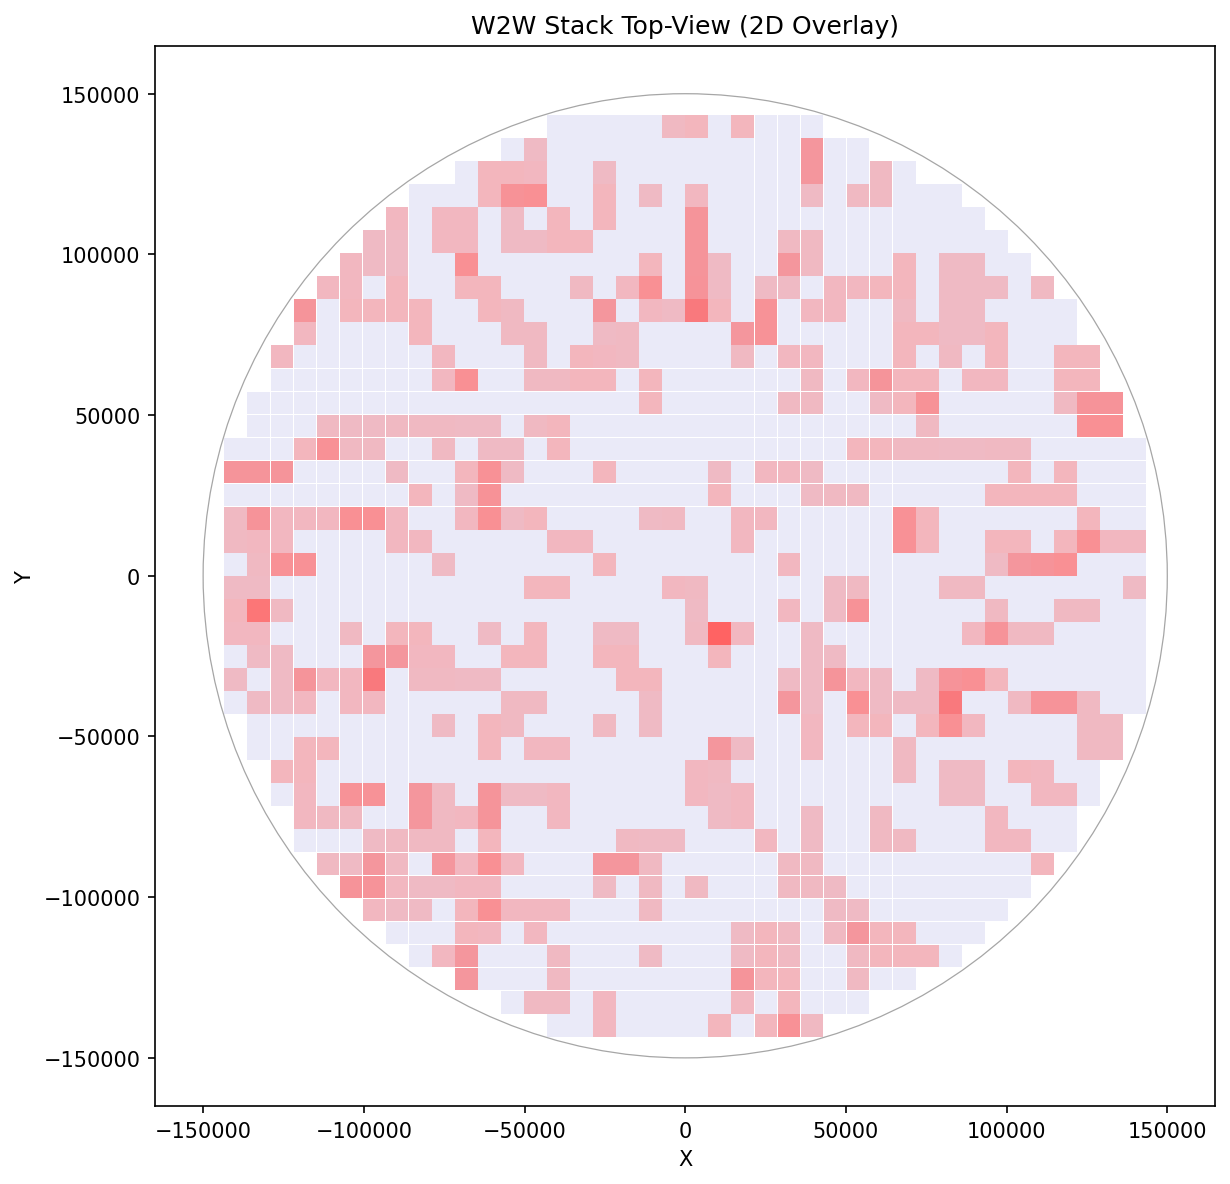

In [77]:
draw_w2w_stack_2d(waf_stack, dpi=150, overlay_all_layers=True, draw_wafer_outline_once=True)

In [78]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, Any, Optional, List, Tuple
import math

@dataclass
class InterfaceYield:
    interface_name: str
    n_die_total: int
    n_die_survived: int
    die_yield: float  # survived/total
    n_die_unknown: int
    n_die_failed: int

def compute_interface_die_yields(waf_stack, *, treat_unknown_as: str = "fail") -> Dict[str, InterfaceYield]:
    """
    计算每个 interface 的 die yield。

    treat_unknown_as:
      - "fail": die.survival is None/缺失 -> 记为失败（默认更保守）
      - "ignore": unknown 不计入 total（只对已标注 die 计算 yield）
      - "survive": unknown 记为 survive（不保守，一般不建议）
    """
    out: Dict[str, InterfaceYield] = {}

    interface_dict = waf_stack.interfaces.interface_dict
    for interface_name, waf_itf in interface_dict.items():
        dies = getattr(waf_itf, "die_list", [])
        n_total = 0
        n_surv = 0
        n_unknown = 0
        n_failed = 0

        for die in dies:
            # survival 可能不存在
            survival = getattr(die, "survival", None)

            if survival is True:
                n_total += 1
                n_surv += 1
            elif survival is False:
                n_total += 1
                n_failed += 1
            else:
                # unknown
                n_unknown += 1
                if treat_unknown_as == "ignore":
                    # 不计入 total
                    pass
                elif treat_unknown_as == "survive":
                    n_total += 1
                    n_surv += 1
                else:  # "fail"
                    n_total += 1
                    n_failed += 1

        die_yield = (n_surv / n_total) if n_total > 0 else float("nan")

        out[interface_name] = InterfaceYield(
            interface_name=interface_name,
            n_die_total=n_total,
            n_die_survived=n_surv,
            die_yield=die_yield,
            n_die_unknown=n_unknown,
            n_die_failed=n_failed
        )

    return out


def compute_die_stack_yield_product(interface_yields: Dict[str, InterfaceYield]) -> float:
    """
    W2W binary stacking 常用的“接口 yield 相乘”定义：
      die_stack_yield = Π_i (die_yield_i)
    """
    ys = []
    for stats in interface_yields.values():
        if stats.n_die_total <= 0 or math.isnan(stats.die_yield):
            continue
        ys.append(stats.die_yield)

    if not ys:
        return float("nan")

    prod = 1.0
    for y in ys:
        prod *= y
    return prod


def compute_die_stack_yield_diewise_all_layers(waf_stack, *, treat_unknown_as: str = "fail") -> float:
    """
    另一种常见定义：按 die 粒度看“整栈存活率”
    - 假设不同 interface 的 die_list 顺序是一致的（die index 对应同一个位置/同一个 die）
    - 只有当一个 die 在所有 interface 都 survive，才算 stack survive

    返回： survived_stack_dies / total_considered_dies
    """
    interface_dict = waf_stack.interfaces.interface_dict
    interfaces = list(interface_dict.items())
    if not interfaces:
        return float("nan")

    # 找到各层 die_list
    die_lists: List[list] = []
    for _, waf_itf in interfaces:
        die_lists.append(getattr(waf_itf, "die_list", []))

    # 需要一个共同长度（取最小，避免越界）
    n = min(len(dl) for dl in die_lists) if die_lists else 0
    if n == 0:
        return float("nan")

    def map_survival(s):
        if s is True:
            return True
        if s is False:
            return False
        # unknown
        if treat_unknown_as == "ignore":
            return None
        if treat_unknown_as == "survive":
            return True
        return False  # fail

    n_total = 0
    n_stack_surv = 0

    for i in range(n):
        per_layer = []
        has_unknown_ignored = False

        for dl in die_lists:
            s = getattr(dl[i], "survival", None)
            s2 = map_survival(s)
            if s2 is None:  # ignore unknown
                has_unknown_ignored = True
                break
            per_layer.append(s2)

        if has_unknown_ignored:
            continue  # 不计入 total

        n_total += 1
        if all(per_layer):
            n_stack_surv += 1

    return (n_stack_surv / n_total) if n_total > 0 else float("nan")


def compute_yields_and_stack(waf_stack, *, stack_mode: str = "product", treat_unknown_as: str = "fail"):
    """
    一站式：返回 (per_interface_stats, die_stack_yield)

    stack_mode:
      - "product": Π interface_yield_i（W2W binary stacking 常用）
      - "diewise": die 粒度“所有层都 survive”的比例
    """
    per_itf = compute_interface_die_yields(waf_stack, treat_unknown_as=treat_unknown_as)

    if stack_mode == "diewise":
        stack_y = compute_die_stack_yield_diewise_all_layers(waf_stack, treat_unknown_as=treat_unknown_as)
    else:
        stack_y = compute_die_stack_yield_product(per_itf)

    return per_itf, stack_y


In [79]:
per_itf, die_stack_yield = compute_yields_and_stack(
    waf_stack,
    stack_mode="product",        # 或 "diewise"
    treat_unknown_as="fail"      # 或 "ignore"
)

print("die_stack_yield =", die_stack_yield)
for k, v in per_itf.items():
    print(k, v.die_yield, v.n_die_survived, "/", v.n_die_total)


die_stack_yield = 0.6278058383931079
Memory_DRAM_0_From_TSV_Interconnect_Die 0.8866459627329193 1142 / 1288
Memory_DRAM_1_From_Memory_DRAM_0 0.8889751552795031 1145 / 1288
Memory_DRAM_2_From_Memory_DRAM_1 0.8913043478260869 1148 / 1288
Memory_DRAM_3_From_Memory_DRAM_2 0.8936335403726708 1151 / 1288


Running assembly yield simulator over 10 wafers...
Verbose mode enabled: Tracking failure reasons for each die.
Simulating stack 1/1 interface 1/4: Memory_DRAM_0_From_TSV_Interconnect_Die...


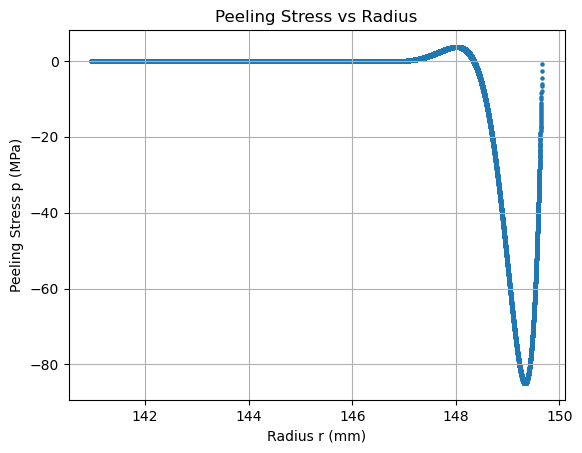

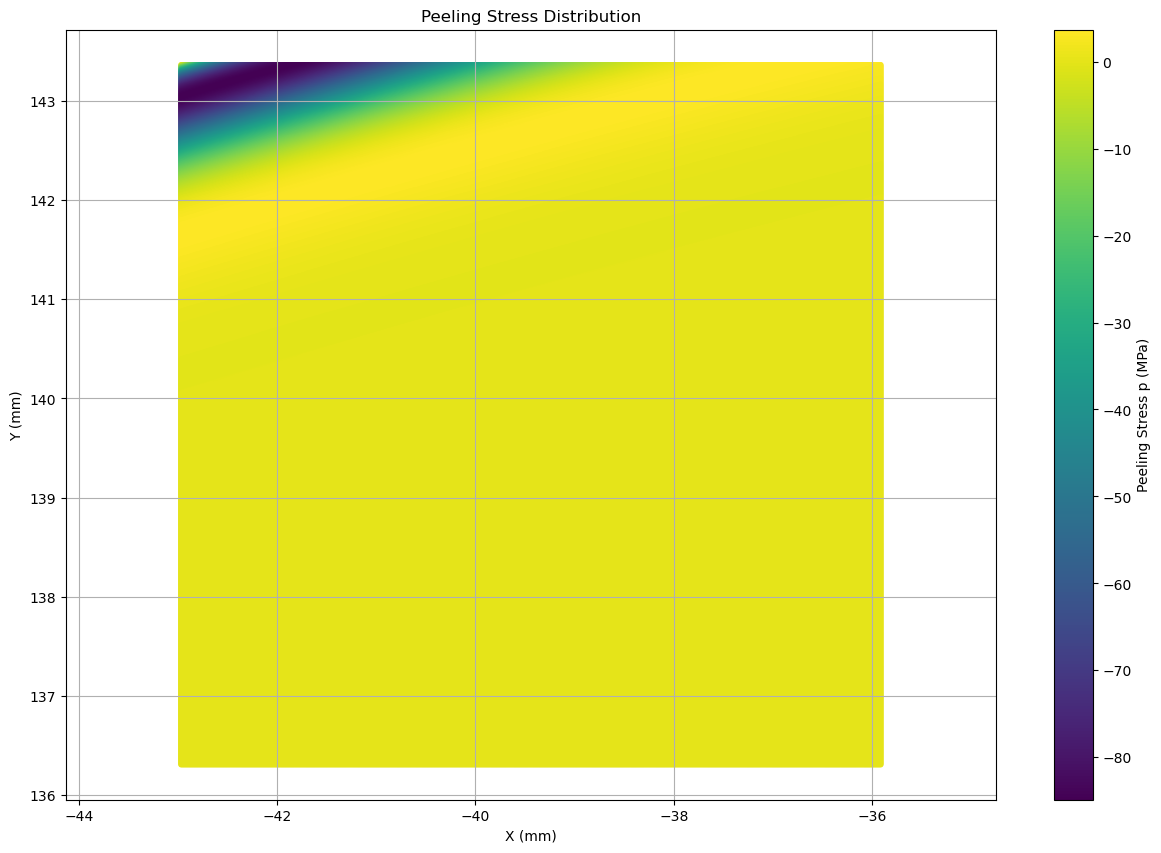

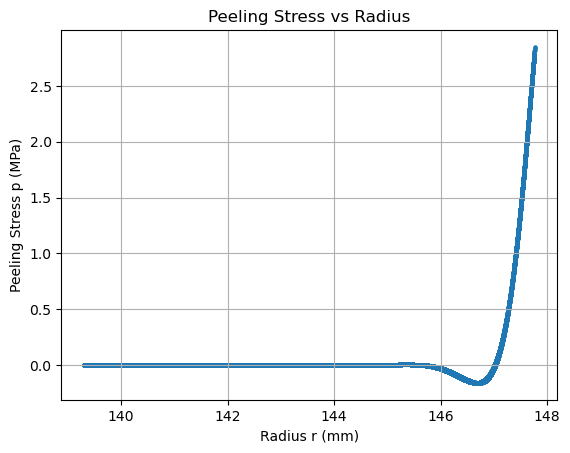

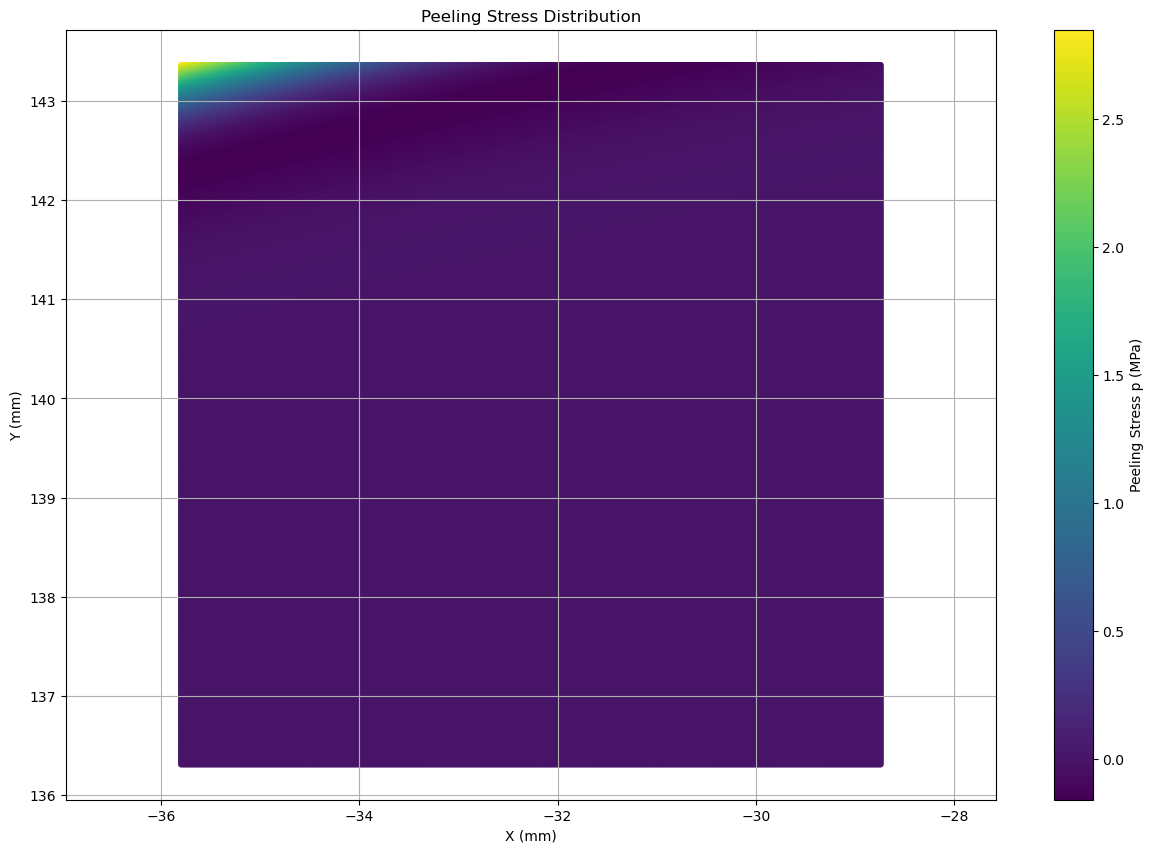

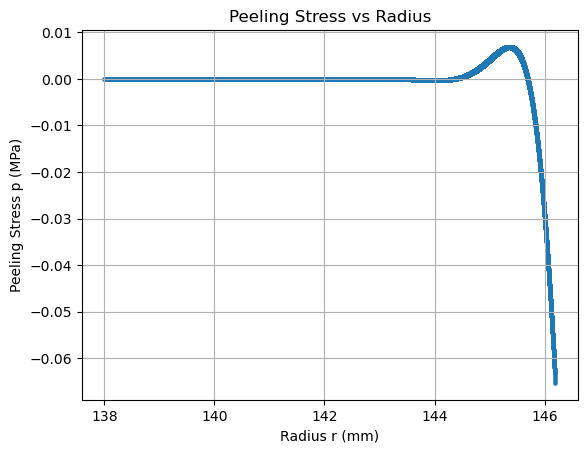

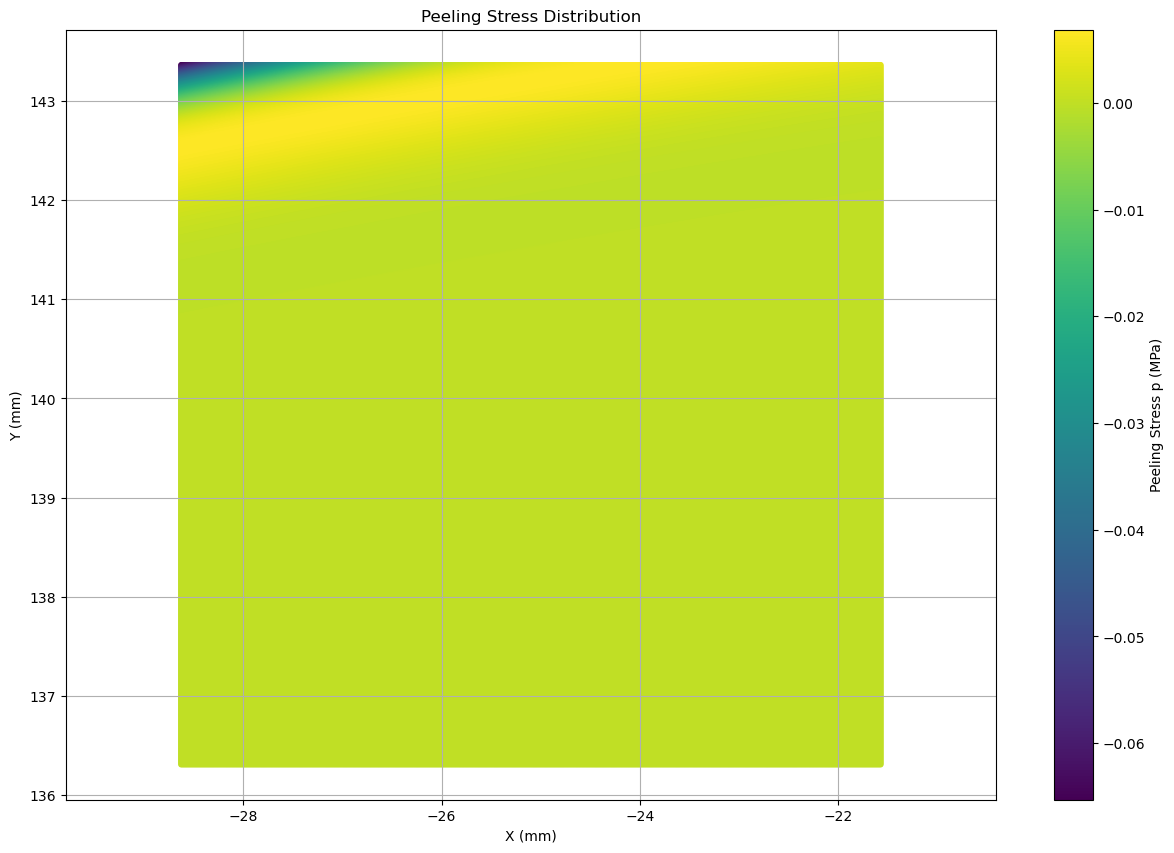

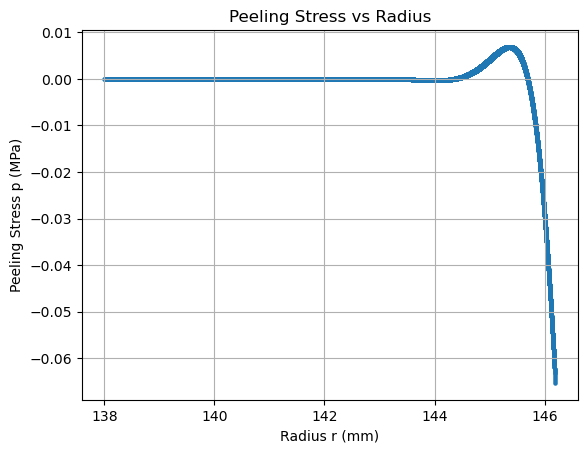

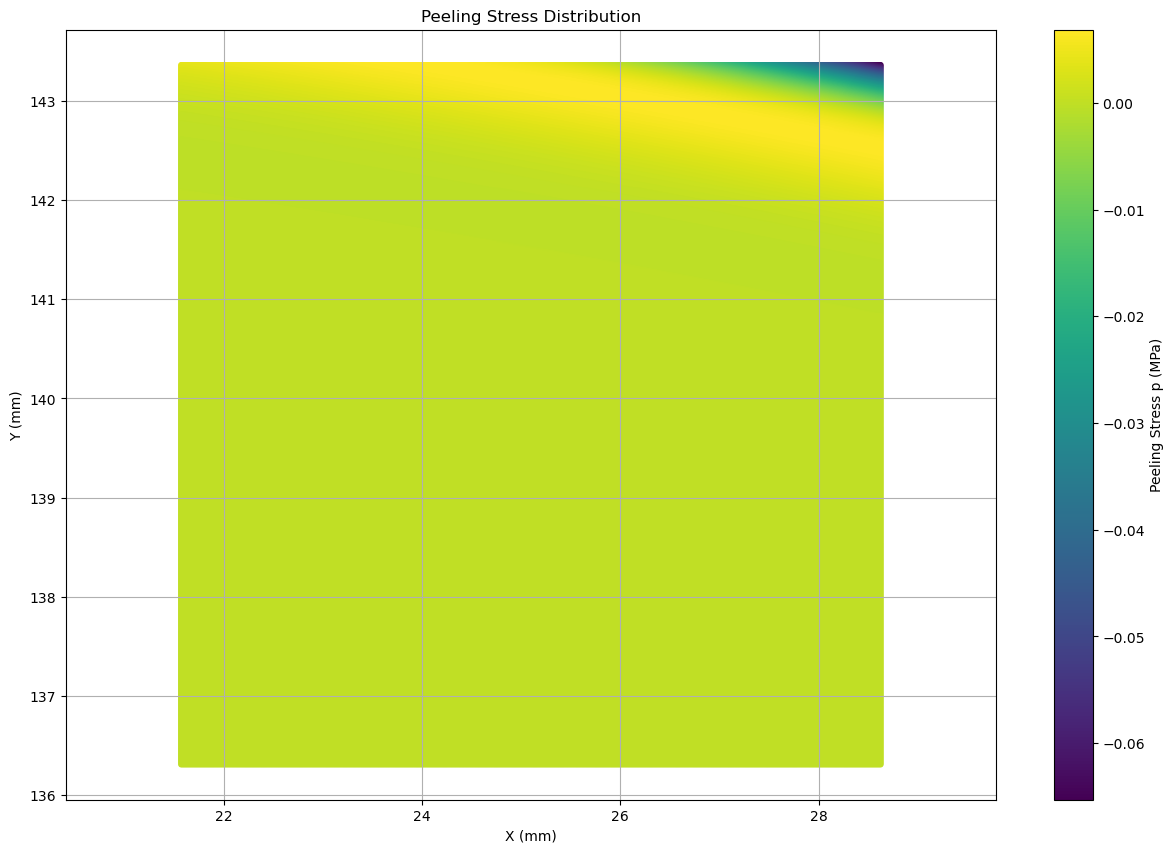

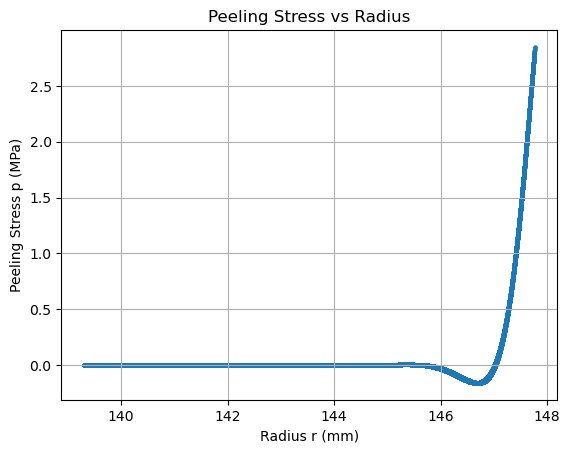

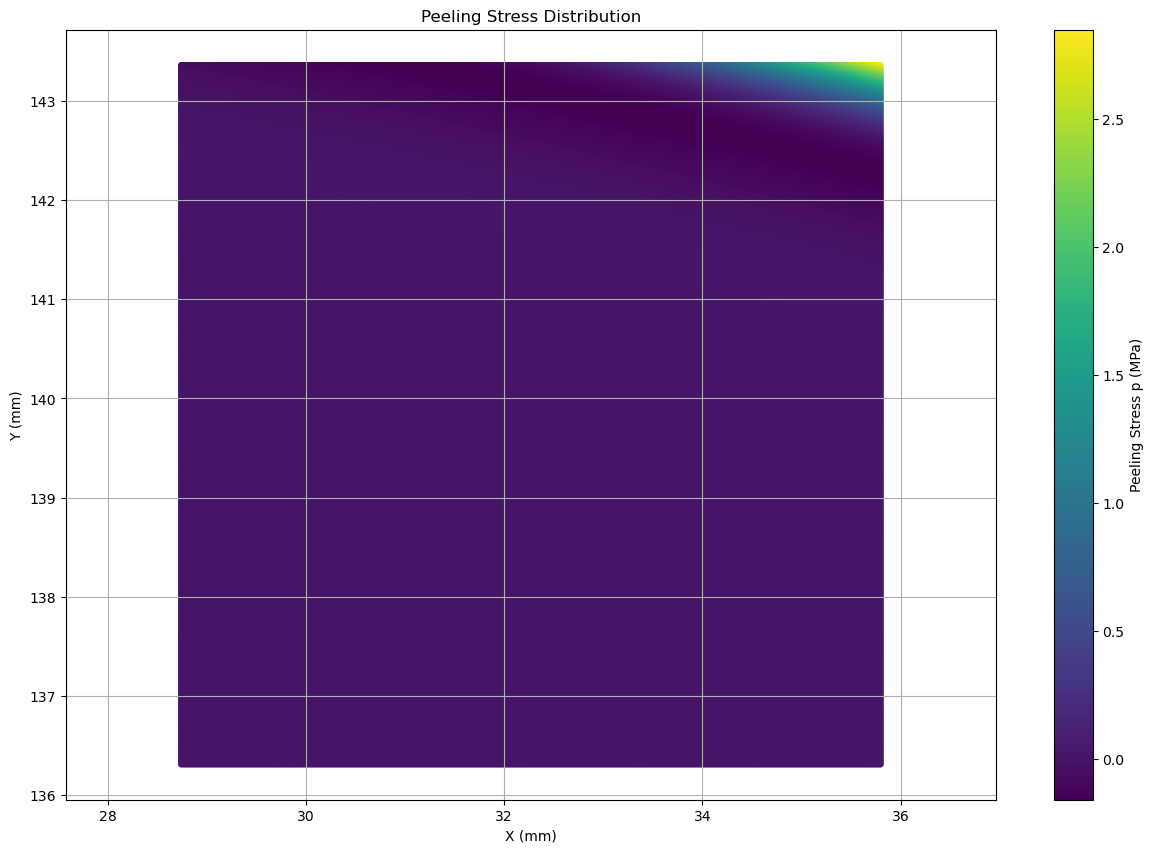

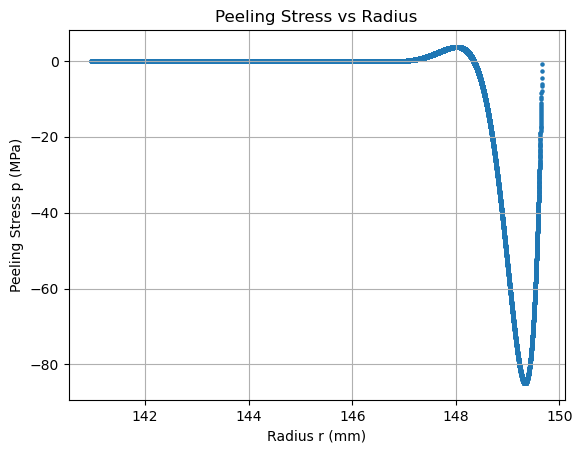

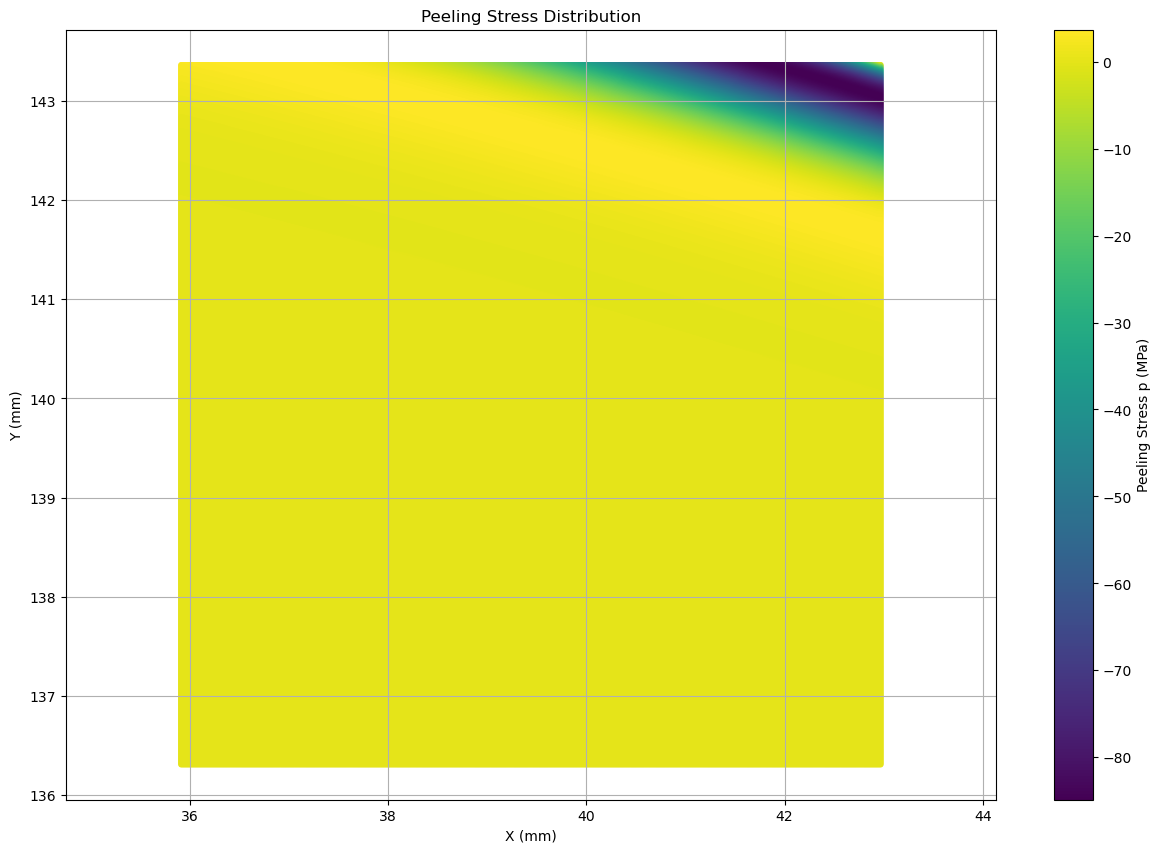

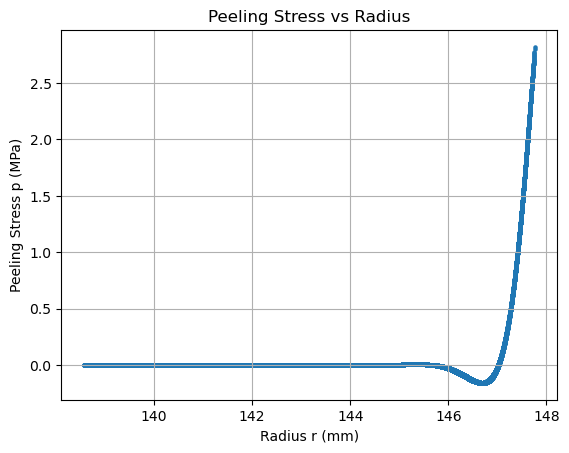

KeyboardInterrupt: 

In [5]:
# Notebook-friendly run (equivalent to the CLI command)
args = SimpleNamespace(
    config="configs/design_6/design_6.yaml",
    mode="w2w_simulation",
    ds_name="design_6",
    ds_dir="input/design_6",
    plot=False,
    verbose=True,
    debug=False,
 )

input_ds_dir = args.ds_dir
_3dbv_path = os.path.join(input_ds_dir, "generated_chiplet_definitions.3dbv")
_3dbx_path = os.path.join(input_ds_dir, "generated_stack_config.3dbx")
cfg_skeleton = OmegaConf.load(args.config)[args.mode]

cfg_dict = get_config_dict(
    cfg_folder=args.config.rsplit("/", 1)[0],
    cfg_skeleton=cfg_skeleton,
    ds_name=args.ds_name,
    input_ds_dir=input_ds_dir,
    _3dbv_path=_3dbv_path,
    _3dbx_path=_3dbx_path,
    mode=args.mode,
    debug=args.debug,
 )

for cfg in cfg_dict.values():
    cfg.plot_flag = args.plot
    cfg.verbose = args.verbose
    output_path = os.path.join(cfg.OUTPUT_DIR, args.ds_name, cfg.INTERFACE)
    os.makedirs(output_path, exist_ok=True)

pad_bitmap_collection_dict = {}
for interface, cfg in cfg_dict.items():
    bmap_path = os.path.join(input_ds_dir, f"{cfg.INTERFACE}.bmap")
    criticality_path = os.path.join(input_ds_dir, f"{cfg.INTERFACE}_criticality.txt")
    pad_bitmap_collection_dict[interface] = convert_3dblox_to_pad_bitmap(
        cfg=cfg,
        _bmap_path=bmap_path,
        criticality_path=criticality_path,
        pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN,
    )

print(f"Running assembly yield simulator over {cfg_skeleton.NUM_WAFER_STACKS} wafers...")
start_time = time.time()
stack_assembly_yield, _ = Assembly_Yield_Simulator(
    input_args=vars(args),
    cfg_skeleton=cfg_skeleton,
    cfg_dict=cfg_dict,
    pad_bitmap_collection_dict=pad_bitmap_collection_dict,
 )

print(f"Yield simulation results for {args.ds_name}: {stack_assembly_yield}")
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))